**Assignment 2 Question 1**


First we import our needed packages and load the data

In [ ]:
import torch
import math
import torch.nn.functional as F
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(mean=0.5, std=1.0)])
train_dataset = datasets.MNIST(root='../data', train=True,
                               download=True, transform=transform)
test_dataset = datasets.MNIST(root='../data', train=False,
                              download=True, transform=transform)


In [22]:
import matplotlib.pyplot as plt

%matplotlib widget

RuntimeError: 'widget' is not a recognised GUI loop or backend name

We then transform our tensors to be the correct size (60000, 784) and also centre the columns of X.

In [13]:
X = train_dataset.data.float().reshape(len(train_dataset), -1)
column_means = X.mean(dim=0, keepdim=True)
X -= column_means
print(X.shape)


torch.Size([60000, 784])


We can now compute the SVD of X

In [14]:
U, S, Vh = torch.linalg.svd(X, full_matrices=False)
print("Shape of U, S and Vh:\n", U.shape, S.shape, Vh.shape)

Shape of U, S and Vh:
 torch.Size([60000, 784]) torch.Size([784]) torch.Size([784, 784])


In [19]:
# First two principal directions
V_2 = Vh[:2, :].T           # shape: [784, 2]

# PCA coordinates for every image
X_pca = X @ V_2    # shape: [60000, 2]

print(X_pca.shape)

torch.Size([60000, 2])


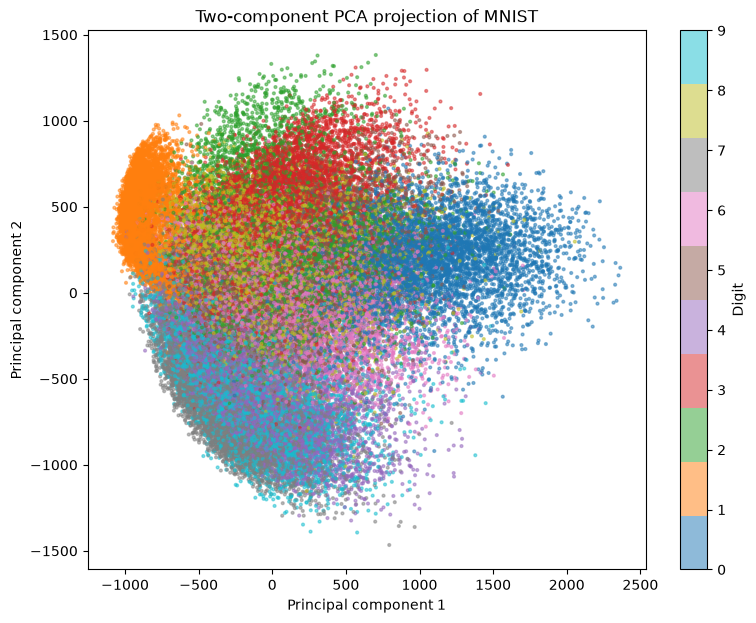

In [17]:
labels = train_dataset.targets

plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    X_pca[:, 0].cpu(),
    X_pca[:, 1].cpu(),
    c=labels.cpu(),
    cmap="tab10",
    s=4,
    alpha=0.5
)

plt.colorbar(scatter, label="Digit")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Two-component PCA projection of MNIST")
plt.show()

torch.Size([60000, 3])


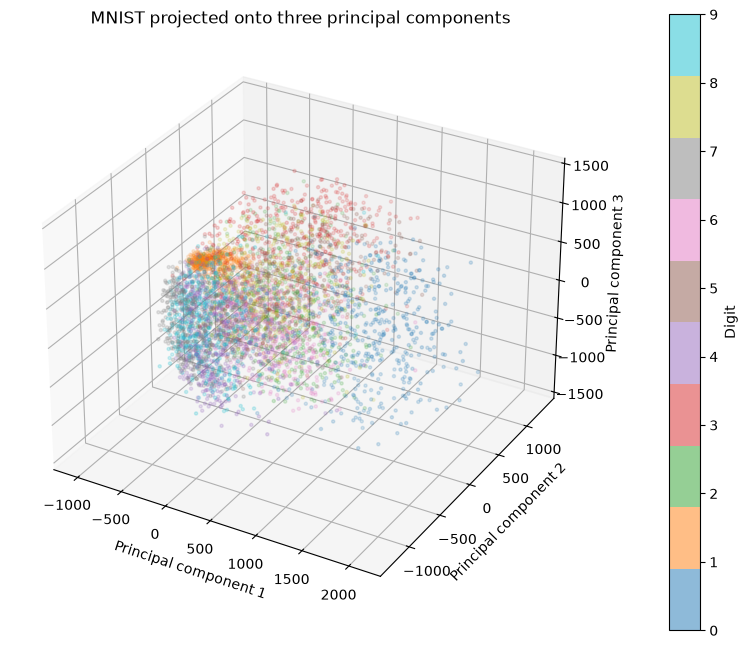

In [21]:
# First three principal directions
V_3 = Vh[:3, :].T              # shape: [784, 3]

# Project centred MNIST images
X_pca_3d = X @ V_3             # shape: [60000, 3]

print(X_pca_3d.shape)

labels = train_dataset.targets

# Plot a subset so the graph remains readable and responsive
n_plot = 5000

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X_pca_3d[:n_plot, 0].cpu(),
    X_pca_3d[:n_plot, 1].cpu(),
    X_pca_3d[:n_plot, 2].cpu(),
    c=labels[:n_plot].cpu(),
    cmap="tab10",
    s=5,
    alpha=0.5
)

ax.set_xlabel("Principal component 1")
ax.set_ylabel("Principal component 2")
ax.set_zlabel("Principal component 3")
ax.set_title("MNIST projected onto three principal components")

fig.colorbar(scatter, ax=ax, label="Digit", pad=0.1)
plt.show()

(0.0, 100000.0)

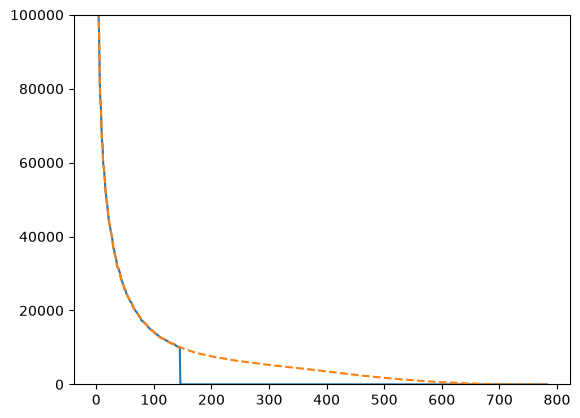

In [10]:
import copy

threshold = 10000.0
S2 = copy.deepcopy(S)
S2[S < threshold] = 0.0

plt.plot(S2)
plt.plot(S, linestyle='dashed')
plt.ylim([0, 100000])
